In [1]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score
import random

import itertools
import os
import pickle as pkl
from pathlib import Path
import concurrent.futures
import functools
import numpy as np
import pandas as pd
import seaborn as sns
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.ephys_plots import plot_brain_regions
from brainbox.io.one import SessionLoader, SpikeSortingLoader
from brainbox.population.decode import get_spike_counts_in_bins
from brainbox.singlecell import bin_spikes2D
from brainbox.task.trials import find_trial_ids, get_event_aligned_raster, get_psth
from brainwidemap import bwm_query, bwm_units, load_good_units, load_trials_and_mask
from brainwidemap.bwm_loading import merge_probes
from iblatlas.atlas import AllenAtlas, BrainRegions
from matplotlib import pyplot as plt
from one.api import ONE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import LeaveOneOut
from sklearn.neural_network import MLPClassifier
from ibl_info.selective_decomposition import filter_eids
from sklearn.svm import SVC
from tqdm import tqdm

import ibl_info.measures.information_measures as info
from ibl_info.prepare_data_pid import get_new_cinc_intervals, prepare_ephys_data
from ibl_info.utils import (
    check_config,
)
from scipy.stats import wilcoxon

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
important_regions = np.asarray(
    [
        "VISp",
        "MOs",
        "SSp-ul",
        "ACAd",
        "PL",
        "CP",
        "VPM",
        "MG",
        "LGd",
        "ZI",
        "SNr",
        "MRN",
        "SCm",
        "PAG",
        "APN",
        "RN",
        "PPN",
        "PRNc",
        "PRNr",
        "GRN",
        "IRN",
        "PGRN",
        "CUL4 5",
        "SIM",
        "IP",
    ]
)

In [4]:
one = ONE()
# unit_df = bwm_units(one)
# # for region in important_regions:
# region = "ZI"
# selective_eids = filter_eids(unit_df, region)

In [5]:
from glob import glob

In [6]:
from ibl_info.decoder_pid import run_decoder_single_session
from ibl_info.stim_prior_results import convert_to_markers

In [7]:
files = glob("../data/generated//bettersessionspid/decoderpid/*.pkl")

In [14]:
with open(files[1], "rb") as f:
    data = pkl.load(f)

In [8]:
def plot_deltas(filename):
    with open(filename, "rb") as f:
        data = pkl.load(f)
    colors = ["#ffc080", "#9bcd9b"]  # congruent, incongruent

    congruent_delta = []
    incongruent_delta = []
    for eid in data.keys():
        congruent_delta.append(data[eid]["congruent_delta"])
        incongruent_delta.append(data[eid]["incongruent_delta"][2])
    congruent_delta = np.asarray(congruent_delta)
    incongruent_delta = np.asarray(incongruent_delta)

    region_name = filename.rsplit("_stim_decoder", 1)[0].rsplit("selective_decomposition_", 1)[1]
    _, p_delta = wilcoxon(congruent_delta, incongruent_delta)
    _, _, marker = convert_to_markers(1, 2, p_delta)

    # fig, ax = plt.subplots()
    # sns.violinplot(data=[congruent_delta, incongruent_delta], palette=colors)
    # ax.spines["top"].set_visible(False)
    # ax.spines["right"].set_visible(False)
    # ax.set_xticks(np.arange(2), ["Congruent", "Incongruent"])
    # ax.set_ylabel("Nonlinear-linear performance")
    # y_max = max(congruent_delta.max(), incongruent_delta.max()) + 0.15
    # bar_height = 0.15
    # x_coords = [0, 0, 1, 1]  # vertical ticks at 0 and 1
    # y_coords = [y_max, y_max + bar_height, y_max + bar_height, y_max]

    # ax.plot(x_coords, y_coords, color="black", linewidth=1.2)
    # ax.text(0.5, y_max + bar_height + 0.01, marker, ha="center", va="bottom")
    # ax.set_title(region_name)
    # ax.set_ylim(-0.5, 1)
    # plt.tight_layout()

    fig, ax = plt.subplots()
    # x1 = np.ones(len(congruent_delta))
    # x2 = np.ones(len(incongruent_delta)) * 2

    # ax.scatter(x1, congruent_delta, color="blue", alpha=0.8, zorder=3)
    # ax.scatter(x2, incongruent_delta, color="green", alpha=0.8, zorder=3)
    # for g1, g2 in zip(congruent_delta, incongruent_delta):
    #     ax.plot([1, 2], [g1, g2], color="gray", alpha=0.6, linewidth=1)
    sns.violinplot([congruent_delta, incongruent_delta], palette=colors, ax=ax)
    ax.set_xticks([0, 1], ["Congruent", "Incongruent"])
    ax.set_ylabel("Nonlinear-linear performance")
    ax.set_title(f"{region_name}")
    # ax.set_xlim(0.5, 2.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()

    return congruent_delta, incongruent_delta

In [ ]:
cdelta = []
ddelta = []
for f in files:
    c, d = plot_deltas(f)
    cdelta.append(c)
    ddelta.append(d)
congruent_delta = np.concatenate(cdelta)
incongruent_delta = np.concatenate(ddelta)

In [10]:
from scipy.stats import mannwhitneyu

In [36]:
data["1b9e349e-93f2-41cc-a4b5-b212d7ddc8df"]["incongruent_delta"]

(0.5696969696969697, 0.5636363636363636, -0.0060606060606061)

In [49]:
def aggregate_data(region_data):

    subsampled_congruent_pid = []
    incongruent_pid = []
    for eid in region_data.keys():
        subsampled_congruent_pid.append(np.mean(region_data[eid]["congruent_pid"], axis=0))
        incongruent_pid.append(region_data[eid]["incongruent_pid"])

    subsampled_congruent_pid = np.concatenate(subsampled_congruent_pid)
    incongruent_pid = np.concatenate(incongruent_pid)

    return (
        subsampled_congruent_pid,
        incongruent_pid,
    )

In [50]:
colors = ["#ffc080", "#9bcd9b"]  # congruent, incongruent

In [15]:
a, b = mannwhitneyu(congruent_delta, incongruent_delta)

np.float64(0.2254780858507186)

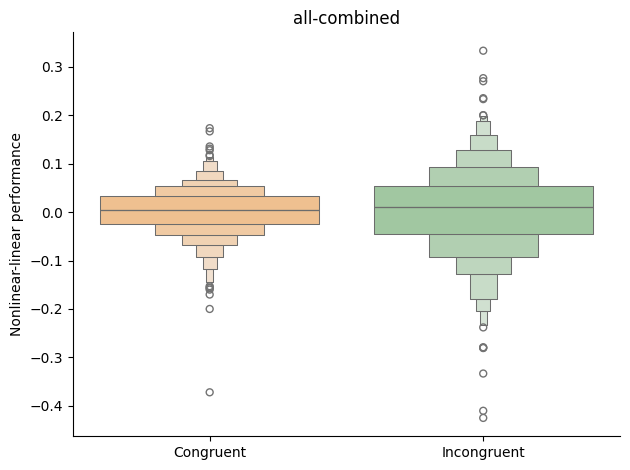

In [28]:
fig, ax = plt.subplots()
x1 = np.ones(len(congruent_delta))
x2 = np.ones(len(incongruent_delta)) * 2

# ax.scatter(x1, congruent_delta, color="blue", alpha=0.8, zorder=3)
# ax.scatter(x2, incongruent_delta, color="green", alpha=0.8, zorder=3)
# for g1, g2 in zip(congruent_delta, incongruent_delta):
#     ax.plot([1, 2], [g1, g2], color="gray", alpha=0.6, linewidth=1)
sns.boxenplot([congruent_delta, incongruent_delta], palette=colors)
ax.set_xticks([0, 1], ["Congruent", "Incongruent"])
ax.set_ylabel("Nonlinear-linear performance")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("all-combined")
plt.tight_layout()

In [51]:
from ibl_info.stim_prior_results import compute_means_and_sems


def plot_pid_region(data, region):
    subsampled_congruent_pid, incongruent_pid = aggregate_data(data)
    _, p_red = wilcoxon(subsampled_congruent_pid[:, 2], incongruent_pid[:, 2])
    _, p_syn = wilcoxon(subsampled_congruent_pid[:, 3], incongruent_pid[:, 3])

    significance_markers = convert_to_markers(0, p_red, p_syn)
    means_pid, sems_pid = compute_means_and_sems(
        incongruent_pid,
        subsampled_congruent_pid,
        incongruent_pid,
    )
    # joint values?
    colors = ["#ffc080", "#9bcd9b"]  # congruent, incongruent
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(
        np.arange(2),
        [means_pid[1, 2], means_pid[1, 3]],
        yerr=[sems_pid[1, 2], sems_pid[1, 3]],
        color=colors[0],
        width=0.3,
        capsize=5,
        edgecolor="k",
        linestyle="dashed",
        label="Congruent",
    )

    ax.bar(
        np.arange(2) + 0.3,
        [means_pid[2, 2], means_pid[2, 3]],
        yerr=[sems_pid[2, 2], sems_pid[2, 3]],
        color=colors[1],
        width=0.3,
        capsize=5,
        edgecolor="k",
        linestyle="dashed",
        label="Incongruent",
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xticks(np.arange(2), ["Redundancy", "Synergy"])
    x_base = np.arange(2)
    bar_width = 0.3
    for i, x_pos in enumerate(x_base):
        x1_bar_pos = x_pos
        x2_bar_pos = x_pos + bar_width

        mean_bar2 = means_pid[1, i + 2]  # means_pid[1, 2] for i=1, means_pid[1,3] for i=2
        sem_bar2 = sems_pid[1, i + 2]

        mean_bar3 = means_pid[2, i + 2]  # pid_means[2, 2] for i=1, pid_means[2,3] for i=2
        sem_bar3 = sems_pid[2, i + 2]

        max_y = max(mean_bar2 + sem_bar2, mean_bar3 + sem_bar3)
        y_sig_line = max_y + 0.001  # Adjust this offset as needed
        y_sig_text = y_sig_line  # Adjust this offset as needed

        marker = significance_markers[i + 1]
        ax.plot([x1_bar_pos, x2_bar_pos], [y_sig_line, y_sig_line], "k-")  # Horizontal line
        ax.text(
            (x1_bar_pos + x2_bar_pos) / 2,  # type: ignore
            y_sig_text,
            marker,
            ha="center",
            va="bottom",
            color="k",
            fontsize=12,
        )
    ax.set_title(f"{region}")
    plt.show()

In [32]:
data

{}

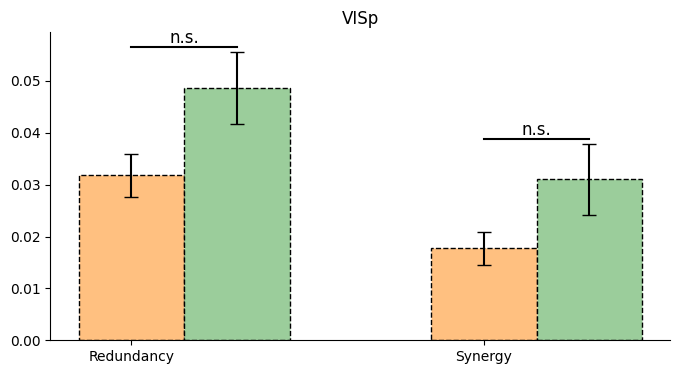

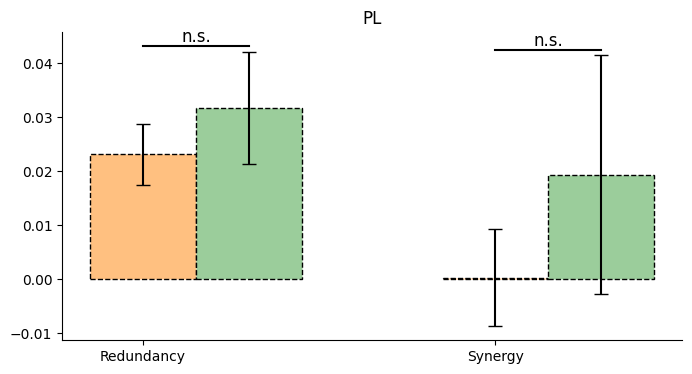

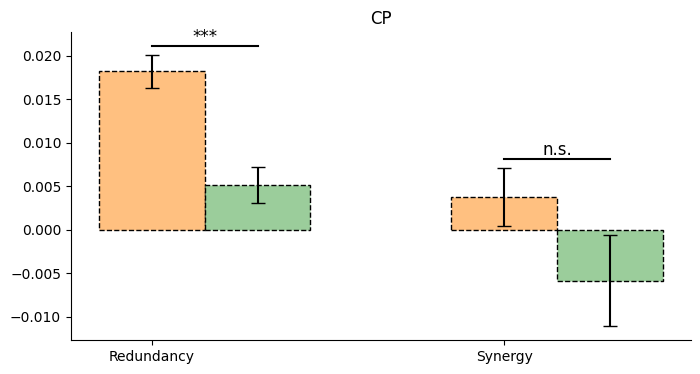

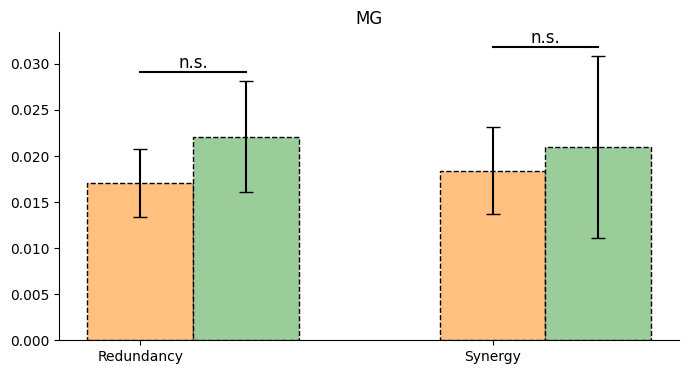

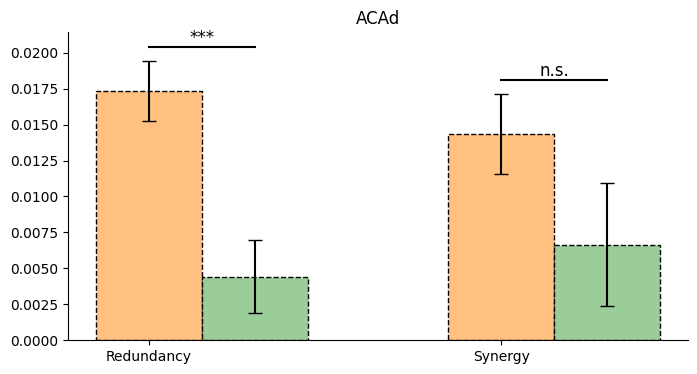

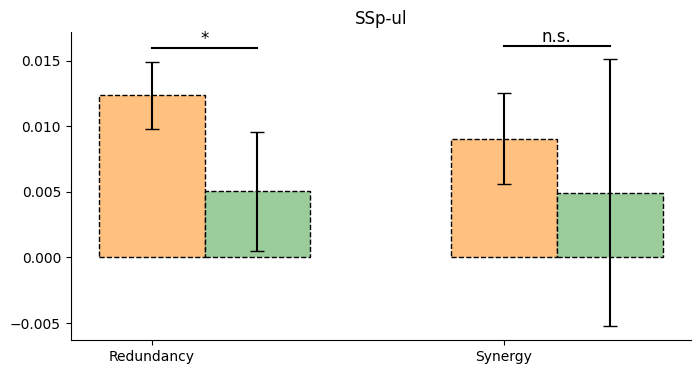

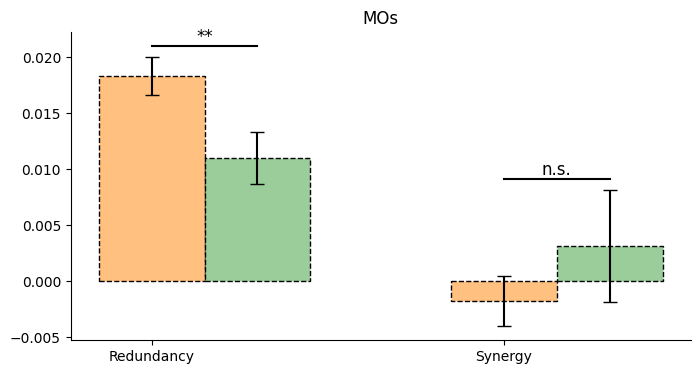

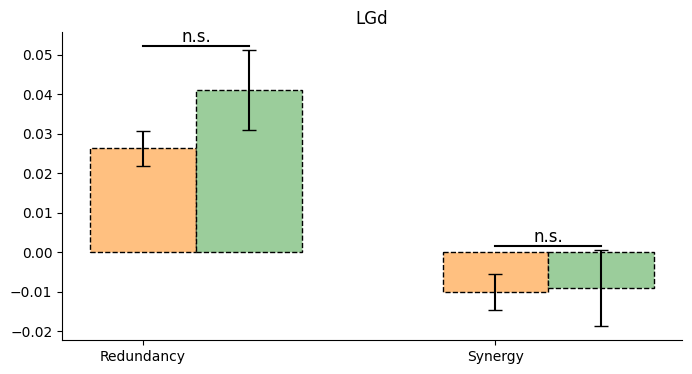

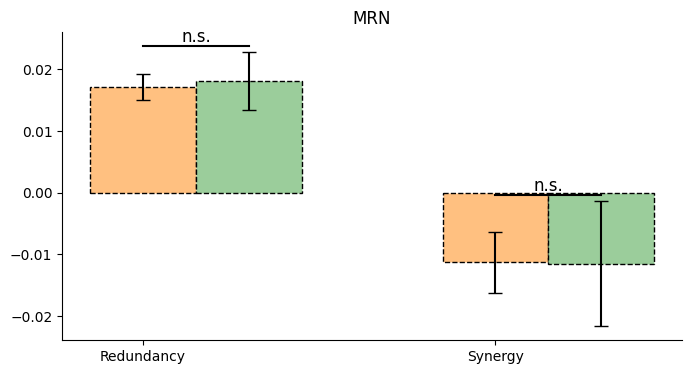

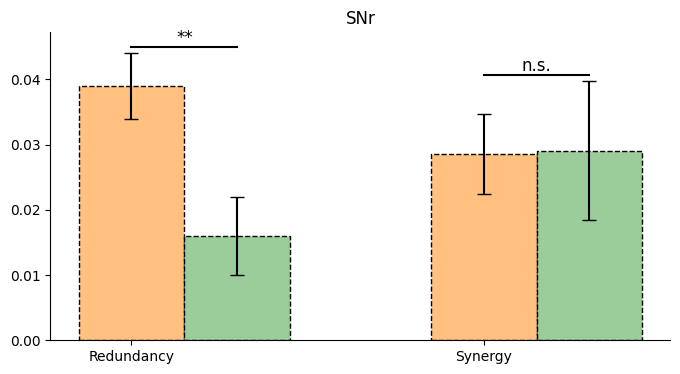

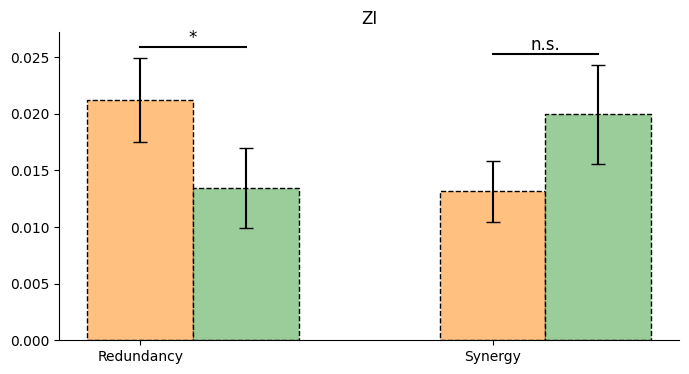

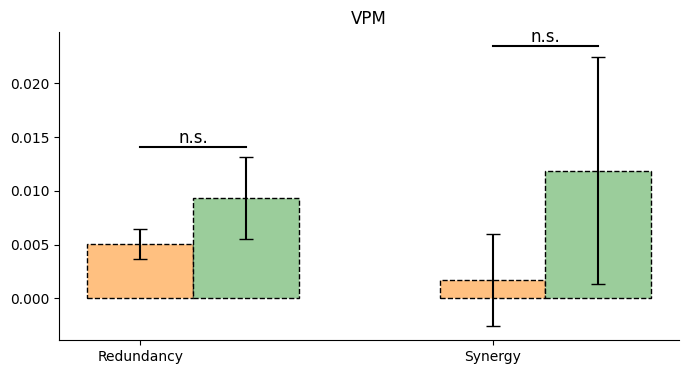

In [52]:
for fname in files:
    with open(fname, "rb") as f:
        data = pkl.load(f)
    if data:
        region_name = fname.rsplit("_stim_decoder", 1)[0].rsplit("selective_decomposition_", 1)[1]
        # print(region_name)
        plot_pid_region(data, region_name)

(150, 6)

In [53]:
def combine(data):
    subsampled_congruent_pid, incongruent_pid = aggregate_data(data)
    return subsampled_congruent_pid, incongruent_pid

In [55]:
cpid = []
incpid = []
for fname in files:
    with open(fname, "rb") as f:
        data = pkl.load(f)
    if data:
        subsampled_congruent_pid, incongruent_pid = combine(data)
        cpid.append(subsampled_congruent_pid)
        incpid.append(incongruent_pid)

In [56]:
cpid = np.concatenate(cpid, axis=0)
incpid = np.concatenate(incpid, axis=0)

In [57]:
def plot_all(subsampled_congruent_pid, incongruent_pid):
    _, p_red = wilcoxon(subsampled_congruent_pid[:, 2], incongruent_pid[:, 2])
    _, p_syn = wilcoxon(subsampled_congruent_pid[:, 3], incongruent_pid[:, 3])

    significance_markers = convert_to_markers(0, p_red, p_syn)
    means_pid, sems_pid = compute_means_and_sems(
        incongruent_pid,
        subsampled_congruent_pid,
        incongruent_pid,
    )
    # joint values?
    colors = ["#ffc080", "#9bcd9b"]  # congruent, incongruent
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(
        np.arange(2),
        [means_pid[1, 2], means_pid[1, 3]],
        yerr=[sems_pid[1, 2], sems_pid[1, 3]],
        color=colors[0],
        width=0.3,
        capsize=5,
        edgecolor="k",
        linestyle="dashed",
        label="Congruent",
    )

    ax.bar(
        np.arange(2) + 0.3,
        [means_pid[2, 2], means_pid[2, 3]],
        yerr=[sems_pid[2, 2], sems_pid[2, 3]],
        color=colors[1],
        width=0.3,
        capsize=5,
        edgecolor="k",
        linestyle="dashed",
        label="Incongruent",
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xticks(np.arange(2), ["Redundancy", "Synergy"])
    x_base = np.arange(2)
    bar_width = 0.3
    for i, x_pos in enumerate(x_base):
        x1_bar_pos = x_pos
        x2_bar_pos = x_pos + bar_width

        mean_bar2 = means_pid[1, i + 2]  # means_pid[1, 2] for i=1, means_pid[1,3] for i=2
        sem_bar2 = sems_pid[1, i + 2]

        mean_bar3 = means_pid[2, i + 2]  # pid_means[2, 2] for i=1, pid_means[2,3] for i=2
        sem_bar3 = sems_pid[2, i + 2]

        max_y = max(mean_bar2 + sem_bar2, mean_bar3 + sem_bar3)
        y_sig_line = max_y + 0.001  # Adjust this offset as needed
        y_sig_text = y_sig_line  # Adjust this offset as needed

        marker = significance_markers[i + 1]
        ax.plot([x1_bar_pos, x2_bar_pos], [y_sig_line, y_sig_line], "k-")  # Horizontal line
        ax.text(
            (x1_bar_pos + x2_bar_pos) / 2,  # type: ignore
            y_sig_text,
            "n.s",
            ha="center",
            va="bottom",
            color="k",
            fontsize=12,
        )
    ax.set_title(f"all")

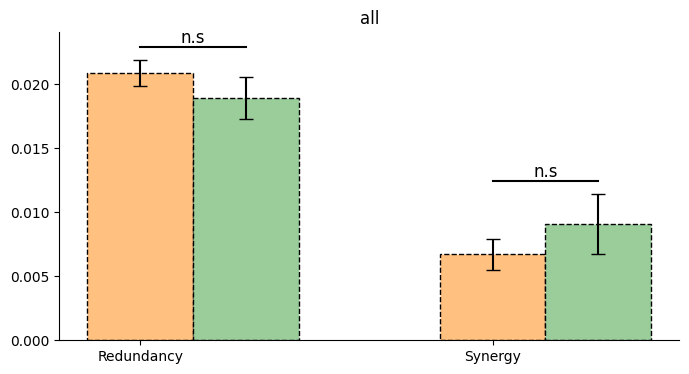

In [58]:
plot_all(cpid, incpid)